# Rayleigh Fading Channel Analysis with Kalman Filter (Ck known)

## 1. Introduction
This notebook investigates the application of Kalman filters for estimating the state of a Rayleigh fading channel. We will focus on the scenario where the transmitted sequence of bits, Ck, is known. The primary objective is to demonstrate the effectiveness of the Kalman filter's three stages: prediction, filtering, and smoothing. We will analyze how stacking these algorithms improves the estimation accuracy. Furthermore, we will assess the algorithm's validity through error analysis and Monte Carlo simulations.

In [6]:
# Setup: add src/ to path and import dependencies
import sys
from pathlib import Path
# Robustly add the project's src/ to sys.path regardless of where Jupyter was launched
p = Path.cwd()
for _ in range(6):
    if (p / 'src').exists():
        sys.path.insert(0, str(p / 'src'))
        break
    if p.parent == p:
        break
    p = p.parent

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

from hmm_project.kalman_rayleigh import (
    create_data,
    kalman_filter_complex,
    rts_smoother_complex,
    run_monte_carlo_simulation
)

## 2. Data Generation

In [7]:
alpha = 0.99
sigma = 0.1
SNR = 15
N = 200
h, y, C, noise_power = create_data(alpha, sigma, SNR, N)

## 3. Kalman Filtering and Smoothing

In [8]:
# Perform Kalman filtering and prediction
kf_results = kalman_filter_complex(y, C, alpha, sigma, noise_power, N)
h_pred = kf_results['h_pred']
h_filt = kf_results['h_filt']
P_filt = kf_results['P_filt']
P_pred = kf_results['P_pred']

# Perform RTS smoothing
smooth_results = rts_smoother_complex(h_filt, P_filt, h_pred, P_pred, alpha, N)
h_smooth = smooth_results['h_smooth']

## 4. Performance Analysis

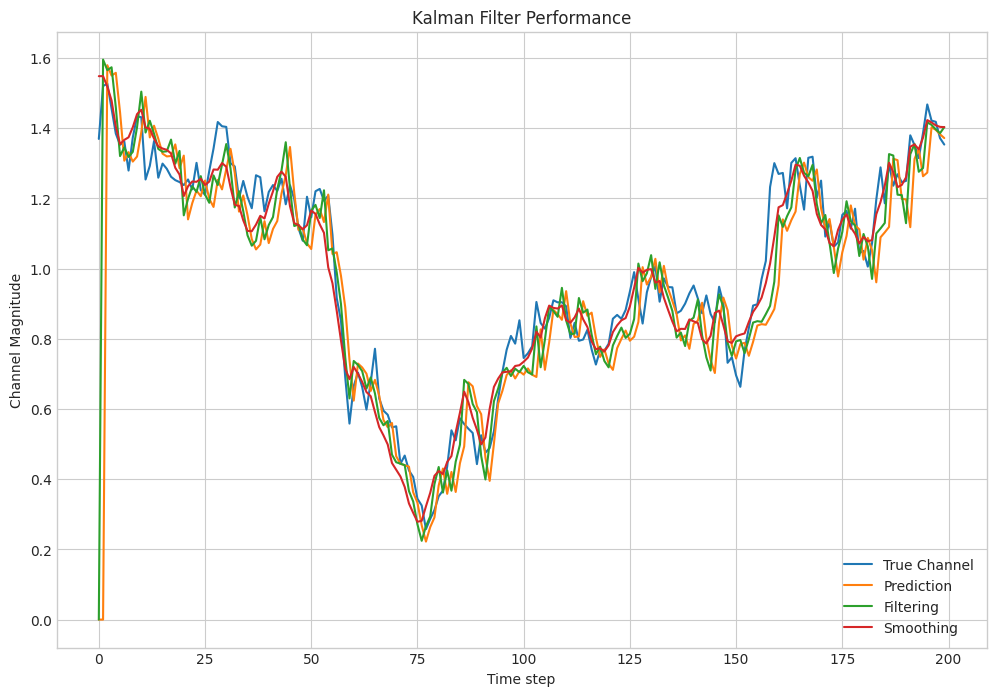

In [9]:
plt.figure(figsize=(12, 8))
plt.plot(np.abs(h), label='True Channel')
plt.plot(np.abs(h_pred), label='Prediction')
plt.plot(np.abs(h_filt), label='Filtering')
plt.plot(np.abs(h_smooth), label='Smoothing')
plt.legend()
plt.title('Kalman Filter Performance')
plt.xlabel('Time step')
plt.ylabel('Channel Magnitude')
plt.grid(True)
plt.show()

In [10]:
mse_pred = np.mean(np.abs(h - h_pred)**2)
mse_filt = np.mean(np.abs(h - h_filt)**2)
mse_smooth = np.mean(np.abs(h - h_smooth)**2)
print(f'MSE Prediction: {mse_pred:.4f}')
print(f'MSE Filtering: {mse_filt:.4f}')
print(f'MSE Smoothing: {mse_smooth:.4f}')

MSE Prediction: 0.0450
MSE Filtering: 0.0247
MSE Smoothing: 0.0094


## 5. Monte Carlo Simulation

/tmp/ipykernel_954/1384010776.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mse_preds, mse_filts, mse_smooths], labels=['Prediction', 'Filtering', 'Smoothing'])


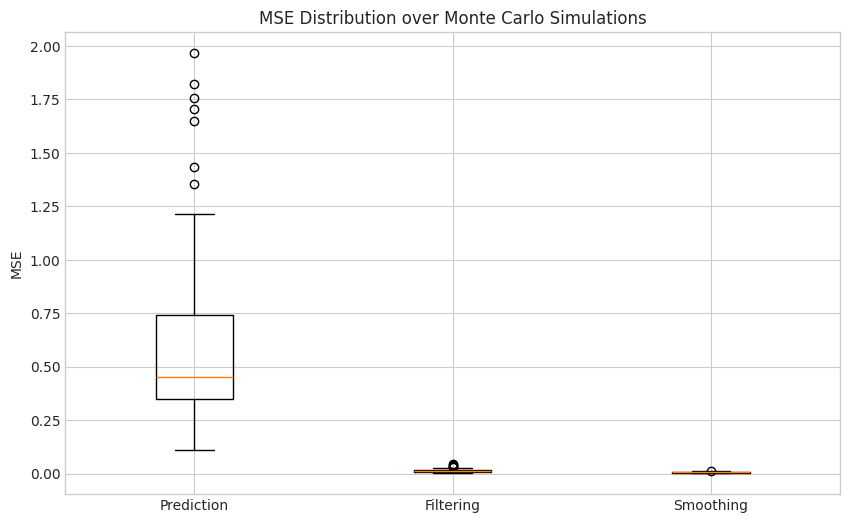

In [11]:
n_simulations = 100
mse_preds, mse_filts, mse_smooths = run_monte_carlo_simulation(n_simulations, alpha, sigma, SNR, N)

plt.figure(figsize=(10, 6))
plt.boxplot([mse_preds, mse_filts, mse_smooths], labels=['Prediction', 'Filtering', 'Smoothing'])
plt.title('MSE Distribution over Monte Carlo Simulations')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

## 6. Conclusion
This notebook demonstrated the use of Kalman filters for channel estimation in a Rayleigh fading environment where the transmitted symbols are known. We observed that the estimation accuracy improves progressively from prediction to filtering, and further to smoothing. The Mean Squared Error (MSE) calculations and the Monte Carlo simulations confirm that the smoothing algorithm provides the most accurate estimation of the channel state. This highlights the benefit of using all available data points to estimate the state at any given time.